In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc


In [2]:
df = pd.read_csv("2015.csv")  
df.head()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENUM,...,_PAREC1,_PASTAE1,_LMTACT1,_LMTWRK1,_LMTSCL1,_RFSEAT2,_RFSEAT3,_FLSHOT6,_PNEUMO2,_AIDTST3
0,1.0,1.0,b'01292015',b'01',b'29',b'2015',1200.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0
1,1.0,1.0,b'01202015',b'01',b'20',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,2.0,2.0,3.0,3.0,4.0,2.0,2.0,NaN,NaN,2.0
2,1.0,1.0,b'02012015',b'02',b'01',b'2015',1200.0,2.015000e+09,2.015000e+09,1.0,...,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,NaN
3,1.0,1.0,b'01142015',b'01',b'14',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,9.0
4,1.0,1.0,b'01142015',b'01',b'14',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0


In [3]:
print(df.shape)
print(df.columns)
print(df.head())


(441456, 330)
Index(['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE',
       'SEQNO', '_PSU', 'CTELENUM',
       ...
       '_PAREC1', '_PASTAE1', '_LMTACT1', '_LMTWRK1', '_LMTSCL1', '_RFSEAT2',
       '_RFSEAT3', '_FLSHOT6', '_PNEUMO2', '_AIDTST3'],
      dtype='object', length=330)
   _STATE  FMONTH        IDATE IMONTH   IDAY    IYEAR  DISPCODE         SEQNO  \
0     1.0     1.0  b'01292015'  b'01'  b'29'  b'2015'    1200.0  2.015000e+09   
1     1.0     1.0  b'01202015'  b'01'  b'20'  b'2015'    1100.0  2.015000e+09   
2     1.0     1.0  b'02012015'  b'02'  b'01'  b'2015'    1200.0  2.015000e+09   
3     1.0     1.0  b'01142015'  b'01'  b'14'  b'2015'    1100.0  2.015000e+09   
4     1.0     1.0  b'01142015'  b'01'  b'14'  b'2015'    1100.0  2.015000e+09   

           _PSU  CTELENUM  ...  _PAREC1  _PASTAE1  _LMTACT1  _LMTWRK1  \
0  2.015000e+09       1.0  ...      4.0       2.0       1.0       1.0   
1  2.015000e+09       1.0  ...      2.0       2.0       3.0    

cleaning the dataset by converting byte string values into normal string format.

Some columns contained byte string values (e.g., b'01292015'), which are not directly usable. I converted them into standard string format during preprocessing to ensure data consistency.

In [4]:
def clean_bytes(x):
    if isinstance(x, str) and x.startswith("b'"):
        return x[2:-1]
    return x

# Apply only on string/object columns
for col in df.select_dtypes(include=['object']):
    df[col] = df[col].map(clean_bytes)



drop the irrelevent columns

In [5]:
drop_cols = ['_STATE','SEQNO','_PSU','IDATE','IMONTH','IDAY','IYEAR',
             'DISPCODE','CTELENUM','PVTRESD1','COLGHOUS']

df.drop(columns=drop_cols, inplace=True, errors='ignore')


Clean DIABETE3
Now:
1 = diabetic
0 = non-diabetic

In [6]:
df = df[df['DIABETE3'].isin([1,2])]
df['DIABETE3'] = df['DIABETE3'].replace({1:1, 2:0})


feature selection

Selected features include clinical indicators (BMI, BP), lifestyle (smoking, exercise), and demographics

In [7]:
features = [
    '_BMI5', 'BPHIGH4', 'BLOODCHO',
    'SMOKE100', 'EXERANY2',
    'GENHLTH', 'MENTHLTH', 'PHYSHLTH',
    'SEX', 'EDUCA', 'INCOME2'
]

X = df[features]
y = df['DIABETE3']


Handle Missing Values

In [8]:
X = X.fillna(X.median(numeric_only=True))


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


correlation heatmap

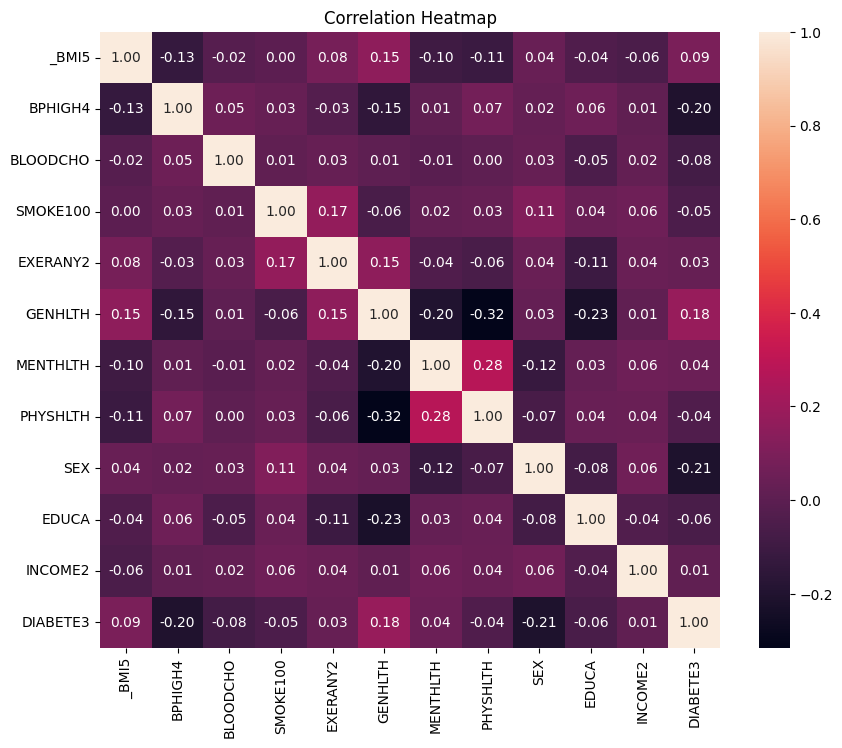

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only your chosen features + target
cols = [
    '_BMI5', 'BPHIGH4', 'BLOODCHO',
    'SMOKE100', 'EXERANY2',
    'GENHLTH', 'MENTHLTH', 'PHYSHLTH',
    'SEX', 'EDUCA', 'INCOME2',
    'DIABETE3'
]

corr = df[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Model Training

Logistic Regression

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

param_lr = {
    'C': [0.1, 1, 10]
}

grid_lr = GridSearchCV(lr, param_lr, cv=5)
grid_lr.fit(X_train, y_train)

lr = grid_lr.best_estimator_

print("Best LR Params:", grid_lr.best_params_)



Best LR Params: {'C': 10}


knn

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(knn, param_knn, cv=5)
grid_knn.fit(X_train, y_train)

knn = grid_knn.best_estimator_

print("Best KNN Params:", grid_knn.best_params_)


Best KNN Params: {'n_neighbors': 7, 'weights': 'uniform'}


svm

In [14]:
import pandas as pd
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_halving_search_cv 
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# 1. Feature Scaling (Mandatory for SVM/SGD)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Model Setup
# We use SGDClassifier with 'hinge' loss to act as a Linear SVM.
# 'class_weight' handles the imbalance in 5 lakh records.
sgd_svm = SGDClassifier(loss='hinge', class_weight='balanced', random_state=42)

# 4. Hyperparameter Grid
param_grid = {
    'alpha': [0.0001, 0.001, 0.01], # Controls regularization
    'penalty': ['l2', 'l1'],       # Types of penalties (L2 is standard for SVM)
}

# 5. Safe & Fast Hyperparameter Tuning
# factor=2 means it doubles the data size each round and keeps the top half of models
search = HalvingGridSearchCV(
    sgd_svm, 
    param_grid, 
    cv=3, 
    factor=2, 
    resource='n_samples', 
    max_resources=len(X_train), 
    aggressive_elimination=True,
    random_state=42,
    verbose=1
)

print("Starting Fast SVM Tuning on 5 Lakh entries...")
search.fit(X_train, y_train)

# 6. Evaluation
best_svm = search.best_estimator_
y_pred = best_svm.predict(X_test)

print("\n--- Best Parameters Found ---")
print(search.best_params_)

print("\n--- SVM Classification Report ---")
print(classification_report(y_test, y_pred, zero_division=0))

Starting Fast SVM Tuning on 5 Lakh entries...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 12172
max_resources_: 48691
aggressive_elimination: True
factor: 2
----------
iter: 0
n_candidates: 6
n_resources: 12172
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 1
n_candidates: 3
n_resources: 24344
Fitting 3 folds for each of 3 candidates, totalling 9 fits
----------
iter: 2
n_candidates: 2
n_resources: 48688
Fitting 3 folds for each of 2 candidates, totalling 6 fits

--- Best Parameters Found ---
{'alpha': 0.01, 'penalty': 'l1'}

--- SVM Classification Report ---
              precision    recall  f1-score   support

         0.0       0.22      0.76      0.35       722
         1.0       0.98      0.83      0.90     11451

    accuracy                           0.83     12173
   macro avg       0.60      0.80      0.62     12173
weighted avg       0.94      0.83      0.87     12173



evaluation

In [15]:
# Logistic Regression predictions
y_pred_lr = lr.predict(X_test)

# KNN predictions
y_pred_knn = knn.predict(X_test)

# SVM predictions (SGD-based)
y_pred_svm = best_svm.predict(X_test)


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }

metrics_lr = get_metrics(y_test, y_pred_lr)
metrics_knn = get_metrics(y_test, y_pred_knn)
metrics_svm = get_metrics(y_test, y_pred_svm)

print("Logistic Regression:", metrics_lr)
print("KNN:", metrics_knn)
print("SVM:", metrics_svm)


Logistic Regression: {'Accuracy': 0.9432350283414114, 'Precision': 0.9476618405724746, 'Recall': 0.994585625709545, 'F1 Score': 0.9705569048532107}
KNN: {'Accuracy': 0.9446315616528382, 'Precision': 0.9535392643716859, 'Recall': 0.989345908654266, 'F1 Score': 0.9711126350077147}
SVM: {'Accuracy': 0.8301158301158301, 'Precision': 0.9822181108027547, 'Recall': 0.8345122696707711, 'F1 Score': 0.902360717658168}


In [17]:
import pandas as pd

comparison_df = pd.DataFrame([metrics_lr, metrics_knn, metrics_svm],
                             index=["Logistic Regression", "KNN", "SVM"])

print(comparison_df)


                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.943235   0.947662  0.994586  0.970557
KNN                  0.944632   0.953539  0.989346  0.971113
SVM                  0.830116   0.982218  0.834512  0.902361


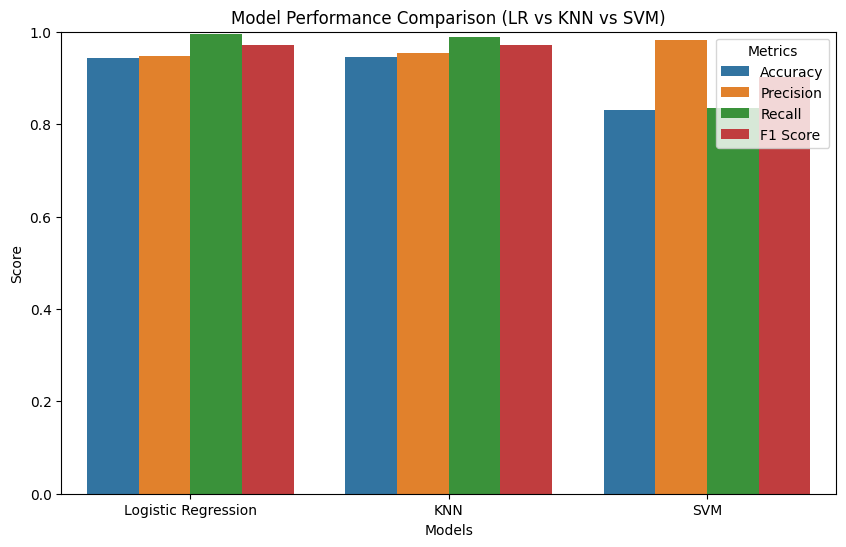

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reset index for seaborn
comparison_df_reset = comparison_df.reset_index()
comparison_df_reset.rename(columns={'index': 'Model'}, inplace=True)

# Convert to long format for seaborn
comparison_melted = comparison_df_reset.melt(id_vars='Model', 
                                             var_name='Metric', 
                                             value_name='Score')

plt.figure(figsize=(10,6))

sns.barplot(data=comparison_melted, 
            x='Model', 
            y='Score', 
            hue='Metric')

plt.title("Model Performance Comparison (LR vs KNN vs SVM)")
plt.ylabel("Score")
plt.xlabel("Models")
plt.ylim(0, 1)

plt.legend(title="Metrics")
plt.show()


In [20]:
best_model_name = comparison_df['F1 Score'].idxmax()

if best_model_name == "Logistic Regression":
    best_model = lr
elif best_model_name == "KNN":
    best_model = knn
else:
    best_model = best_svm

print(f"Best Model Selected: {best_model_name}")


Best Model Selected: KNN


confusion matrix

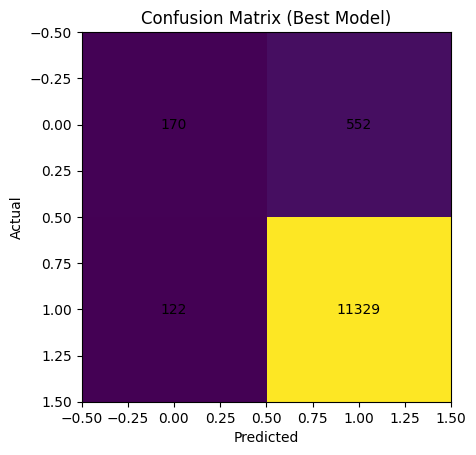

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()


roc curve

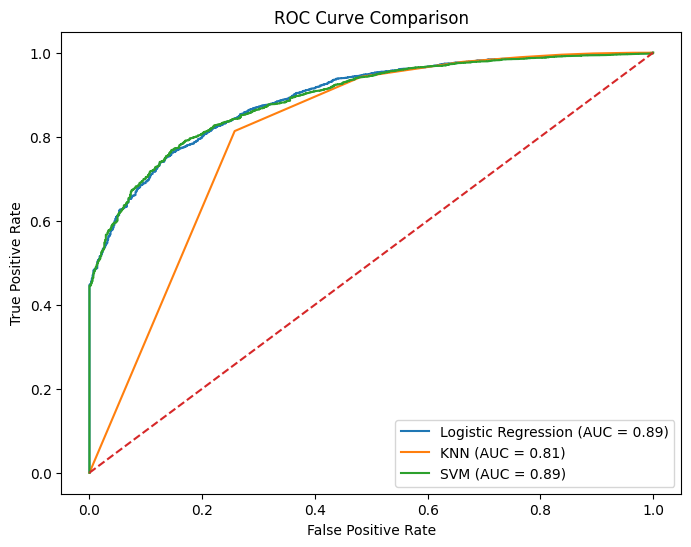

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# --- Logistic Regression ---
y_prob_lr = lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# --- KNN ---
y_prob_knn = knn.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

# --- SVM (SGDClassifier: use decision_function) ---
y_scores_svm = best_svm.decision_function(X_test)

# Normalize scores to [0,1] (for ROC compatibility)
y_prob_svm = (y_scores_svm - y_scores_svm.min()) / (y_scores_svm.max() - y_scores_svm.min())

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

# --- Plot all curves ---
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")

# Diagonal line (random model)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


creating pickel file

1.save model

In [23]:
import pickle

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Best model and scaler saved successfully.")


Best model and scaler saved successfully.


Loading model

In [24]:
with open('best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

print("Model loaded successfully.")


Model loaded successfully.


Taking user input

In [26]:
import pandas as pd

# Feature names (same as training)
feature_names = [
    '_BMI5', 'BPHIGH4', 'BLOODCHO', 'SMOKE100', 'EXERANY2', 
    'GENHLTH', 'MENTHLTH', 'PHYSHLTH', 'SEX', 'EDUCA', 'INCOME2'
]

print("Enter Patient Details:\n")

bmi = float(input("Enter BMI: "))
bp = int(input("High BP (1=Yes, 0=No): "))
chol = int(input("High Cholesterol (1=Yes, 0=No): "))
smoke = int(input("Smoked 100 cigarettes (1=Yes, 0=No): "))
exercise = int(input("Exercise (1=Yes, 0=No): "))
genhlth = int(input("General Health (1-5): "))
menthlth = int(input("Mental Health Days (0-30): "))
physhlth = int(input("Physical Health Days (0-30): "))
sex = int(input("Sex (1=Male, 0=Female): "))
educa = int(input("Education (1-6): "))
income = int(input("Income (1-8): "))

# Create DataFrame
user_df = pd.DataFrame([[bmi, bp, chol, smoke, exercise, genhlth,
                         menthlth, physhlth, sex, educa, income]],
                       columns=feature_names)

print("\nInput captured successfully!")


Enter Patient Details:



Enter BMI:  28
High BP (1=Yes, 0=No):  1
High Cholesterol (1=Yes, 0=No):  1
Smoked 100 cigarettes (1=Yes, 0=No):  0
Exercise (1=Yes, 0=No):  0
General Health (1-5):  3
Mental Health Days (0-30):  15
Physical Health Days (0-30):  16
Sex (1=Male, 0=Female):  0
Education (1-6):  4
Income (1-8):  5



Input captured successfully!


scaling and final prediction

ouput

In [27]:
import numpy as np

# Scale input
user_scaled = loaded_scaler.transform(user_df)

# Prediction
prediction = loaded_model.predict(user_scaled)

# Confidence handling
if hasattr(loaded_model, "predict_proba"):
    prob = loaded_model.predict_proba(user_scaled)
    confidence = np.max(prob) * 100
else:
    score = loaded_model.decision_function(user_scaled)
    confidence = (1 / (1 + np.exp(-score)))[0] * 100  # sigmoid approx

# Output result
print("\n" + "="*40)
if prediction[0] == 1:
    print("Prediction: DIABETIC")
else:
    print("Prediction: NOT DIABETIC")

print(f"Confidence Level: {confidence:.2f}%")
print("="*40)



Prediction: DIABETIC
Confidence Level: 100.00%
